In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
train = pd.read_csv("../dataset/cleaned/train_processed.csv")

train.head()

,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,...,GarageArea,OpenPorchSF,ExterQual_Gd,ExterQual_TA,Foundation_PConc,BsmtQual_TA,BsmtFinType1_GLQ,KitchenQual_TA,GarageFinish_Unf,SalePrice
0,-0.333244,0.652644,1.053246,0.878668,1.230517,-0.488321,-0.830489,0.428636,0.789741,0.981148,...,0.373509,0.863737,1.411313,-1.278819,1.120968,-0.941438,1.578868,-1.006873,-0.941438,208500.0
1,-0.013189,-0.073068,0.156179,-0.429577,-0.809621,0.532289,0.289638,-0.502349,0.789741,-0.316385,...,-0.051541,-1.077559,-0.708560,0.781971,-0.892086,-0.941438,-0.633365,0.993174,-0.941438,181500.0
2,0.446022,0.652644,0.986797,0.830215,1.157359,-0.327437,-0.653917,0.586571,0.789741,-0.316385,...,0.663315,0.691611,1.411313,-1.278819,1.120968,-0.941438,1.578868,-1.006873,-0.941438,223500.0
3,-0.027104,0.652644,-1.870528,-0.720298,-0.809621,-0.739702,-0.540801,0.443182,-1.026041,0.332382,...,0.827539,0.608034,-0.708560,0.781971,-0.892086,1.062205,-0.633365,-1.006873,1.062205,140000.0
4,1.283733,1.378355,0.953572,0.733308,1.453554,0.238172,-0.033157,1.442744,0.789741,1.629914,...,1.764579,1.012147,1.411313,-1.278819,1.120968,-0.941438,1.578868,-1.006873,-0.941438,250000.0


In [22]:
correlation = train.corr()["SalePrice"]

correlation.sort_values(ascending=False)

SalePrice           1.000000
OverallQual         0.817680
GrLivArea           0.729311
GarageCars          0.675896
GarageArea          0.660029
TotalBsmtSF         0.645251
1stFlrSF            0.621873
FullBath            0.583994
YearBuilt           0.570327
YearRemodAdd        0.552061
TotRmsAbvGrd        0.539339
Foundation_PConc    0.535107
ExterQual_Gd        0.526232
GarageYrBlt         0.499210
Fireplaces          0.488253
OpenPorchSF         0.466298
BsmtFinType1_GLQ    0.455983
LotArea             0.435876
MasVnrArea          0.413826
BsmtQual_TA        -0.542610
KitchenQual_TA     -0.561153
GarageFinish_Unf   -0.561158
ExterQual_TA       -0.630016
Name: SalePrice, dtype: float64

In [23]:
check_corr = correlation.abs()
check_corr

LotArea             0.435876
OverallQual         0.817680
YearBuilt           0.570327
YearRemodAdd        0.552061
MasVnrArea          0.413826
TotalBsmtSF         0.645251
1stFlrSF            0.621873
GrLivArea           0.729311
FullBath            0.583994
TotRmsAbvGrd        0.539339
Fireplaces          0.488253
GarageYrBlt         0.499210
GarageCars          0.675896
GarageArea          0.660029
OpenPorchSF         0.466298
ExterQual_Gd        0.526232
ExterQual_TA        0.630016
Foundation_PConc    0.535107
BsmtQual_TA         0.542610
BsmtFinType1_GLQ    0.455983
KitchenQual_TA      0.561153
GarageFinish_Unf    0.561158
SalePrice           1.000000
Name: SalePrice, dtype: float64

In [24]:
max(check_corr)

1.0

In [25]:
top_features = correlation.abs().sort_values(ascending=False).index[1:6]

top_features

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF'], dtype='str')

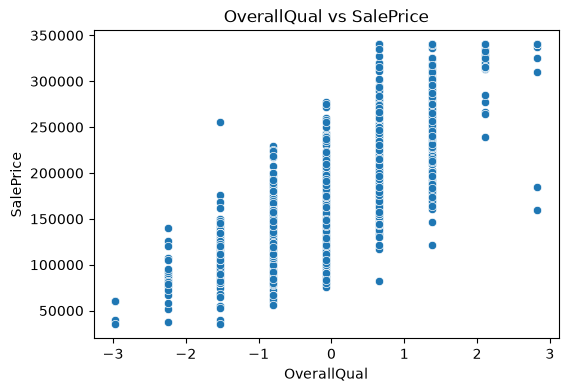

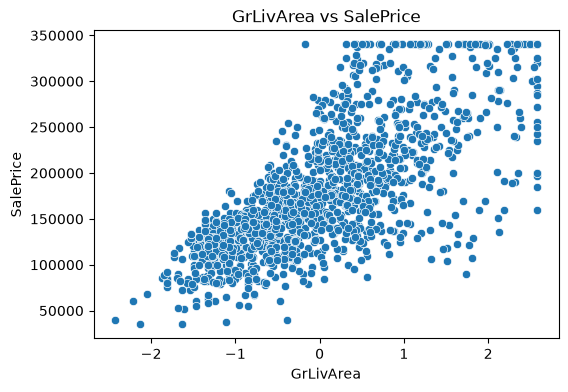

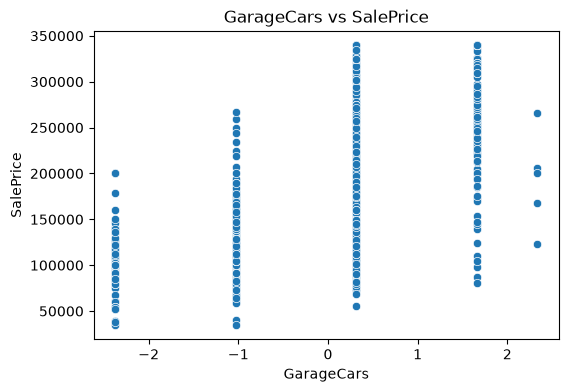

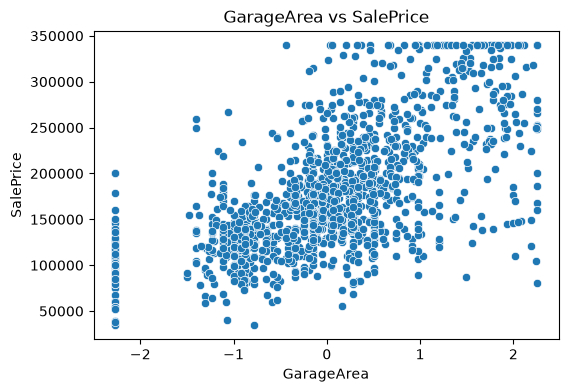

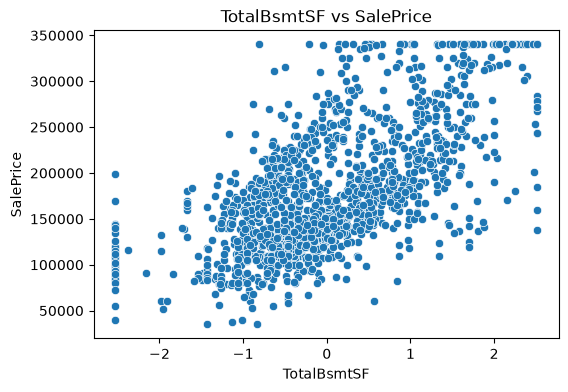

In [26]:
for column in top_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=train[column],
        y=train["SalePrice"]
    )

    plt.title(f"{column} vs SalePrice")

    plt.show()

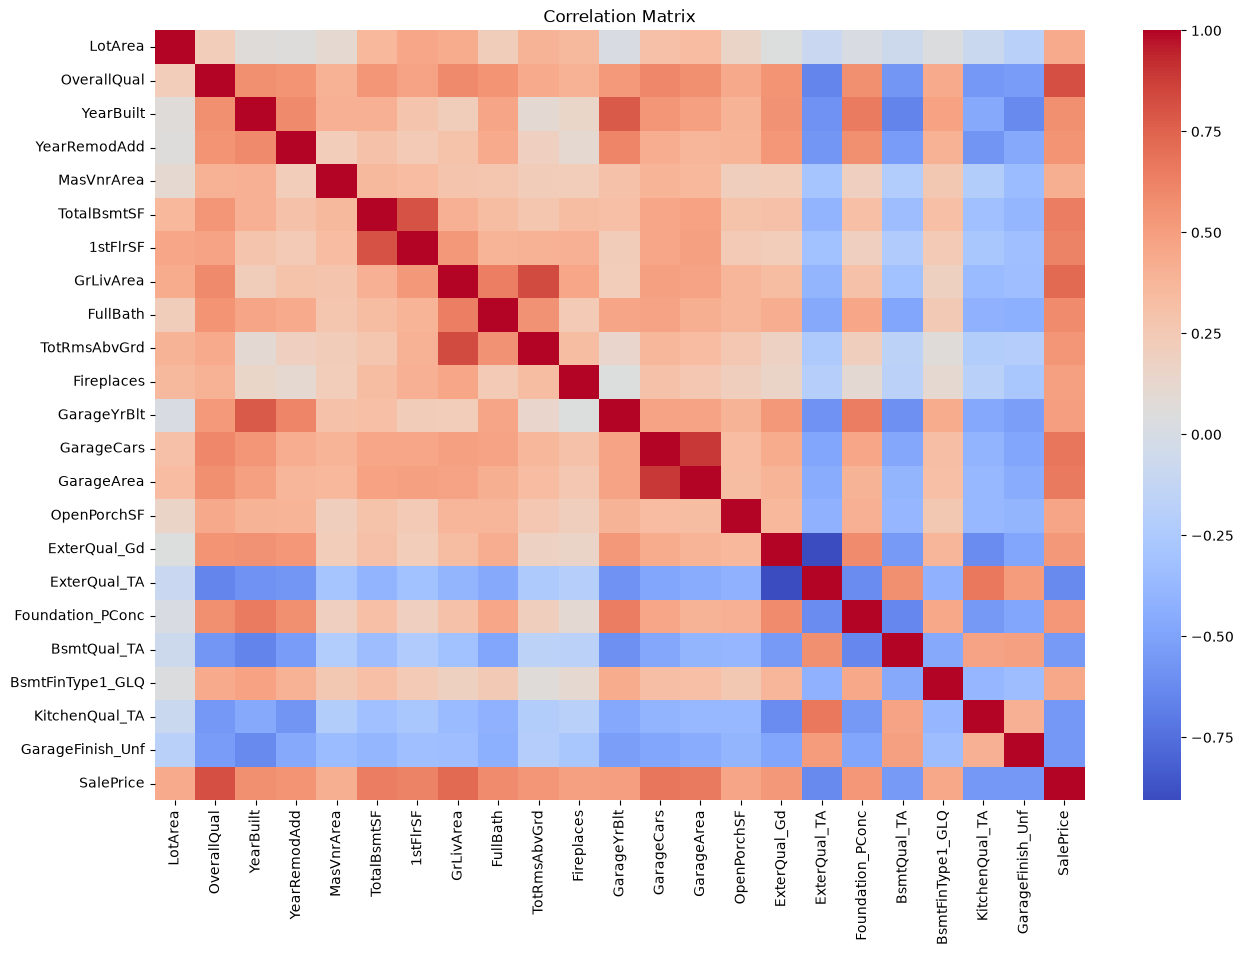

In [27]:
plt.figure(figsize=(15,10))

sns.heatmap(
    train.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [28]:
correlation.sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.817680
GrLivArea       0.729311
GarageCars      0.675896
GarageArea      0.660029
TotalBsmtSF     0.645251
1stFlrSF        0.621873
FullBath        0.583994
YearBuilt       0.570327
YearRemodAdd    0.552061
Name: SalePrice, dtype: float64

In [29]:
correlation.sort_values().head(10)

ExterQual_TA       -0.630016
GarageFinish_Unf   -0.561158
KitchenQual_TA     -0.561153
BsmtQual_TA        -0.542610
MasVnrArea          0.413826
LotArea             0.435876
BsmtFinType1_GLQ    0.455983
OpenPorchSF         0.466298
Fireplaces          0.488253
GarageYrBlt         0.499210
Name: SalePrice, dtype: float64

In [30]:
important_features = [
    "GrLivArea",
    "TotalBsmtSF",
    "GarageArea",
    "SalePrice",
    "GarageCars",
    "OverallQual"
]

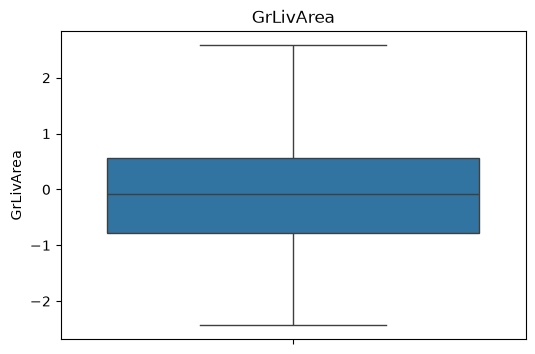

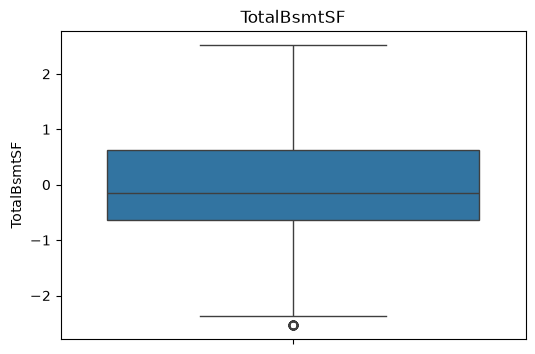

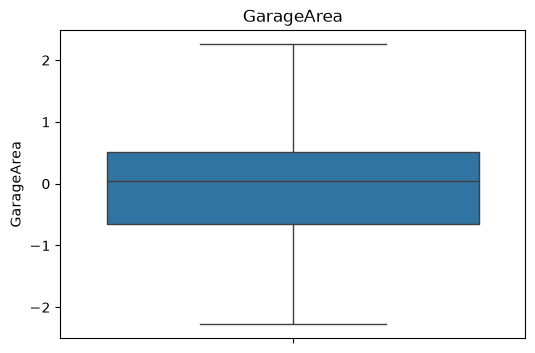

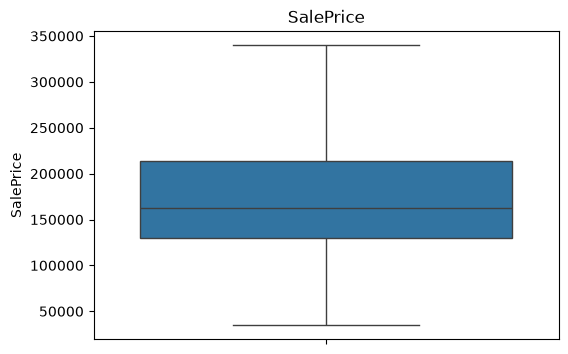

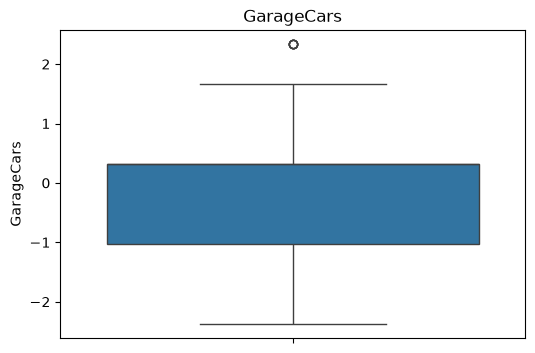

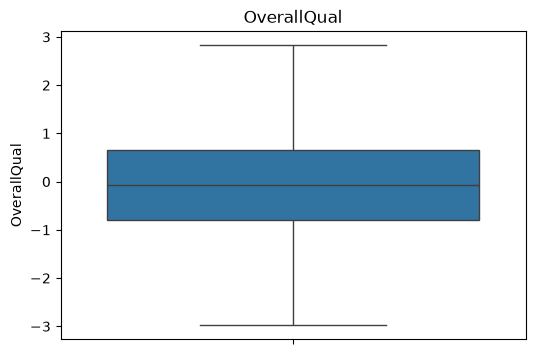

In [31]:
for column in important_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        y=train[column]
    )

    plt.title(column)

    plt.show()

In [32]:
feature_importance = correlation.abs().sort_values(
    ascending=False
)

feature_importance.head(15)

SalePrice           1.000000
OverallQual         0.817680
GrLivArea           0.729311
GarageCars          0.675896
GarageArea          0.660029
TotalBsmtSF         0.645251
ExterQual_TA        0.630016
1stFlrSF            0.621873
FullBath            0.583994
YearBuilt           0.570327
GarageFinish_Unf    0.561158
KitchenQual_TA      0.561153
YearRemodAdd        0.552061
BsmtQual_TA         0.542610
TotRmsAbvGrd        0.539339
Name: SalePrice, dtype: float64

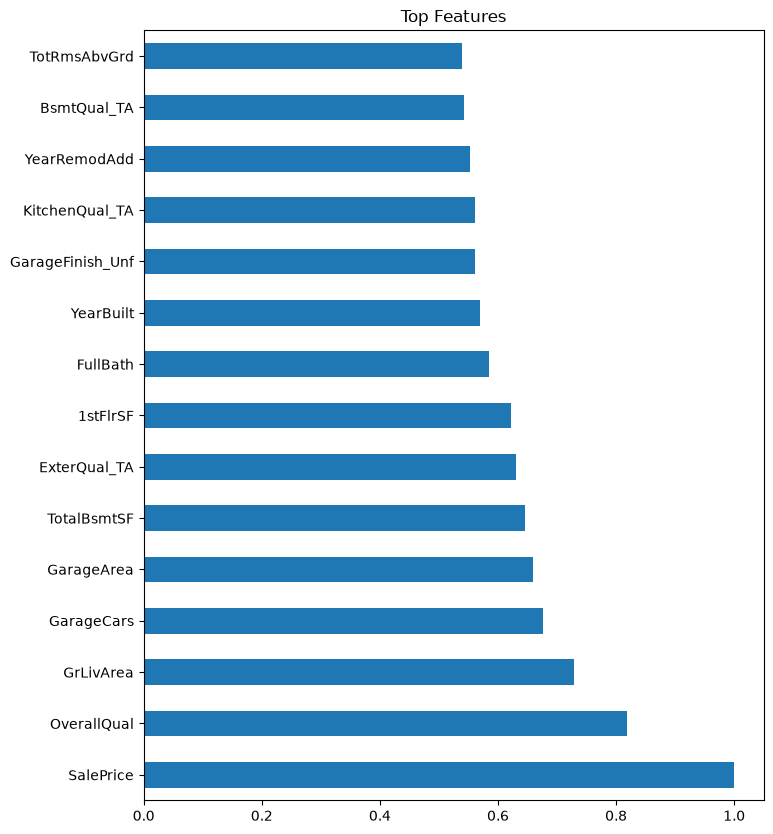

In [33]:
plt.figure(figsize=(8,10))

feature_importance.head(15).plot(
    kind="barh"
)

plt.title("Top Features")

plt.show()

In [34]:
selected_columns = [
    "GrLivArea",
    "TotalBsmtSF",
    "GarageArea",
    "SalePrice",
    "GarageCars",
    "OverallQual"
]

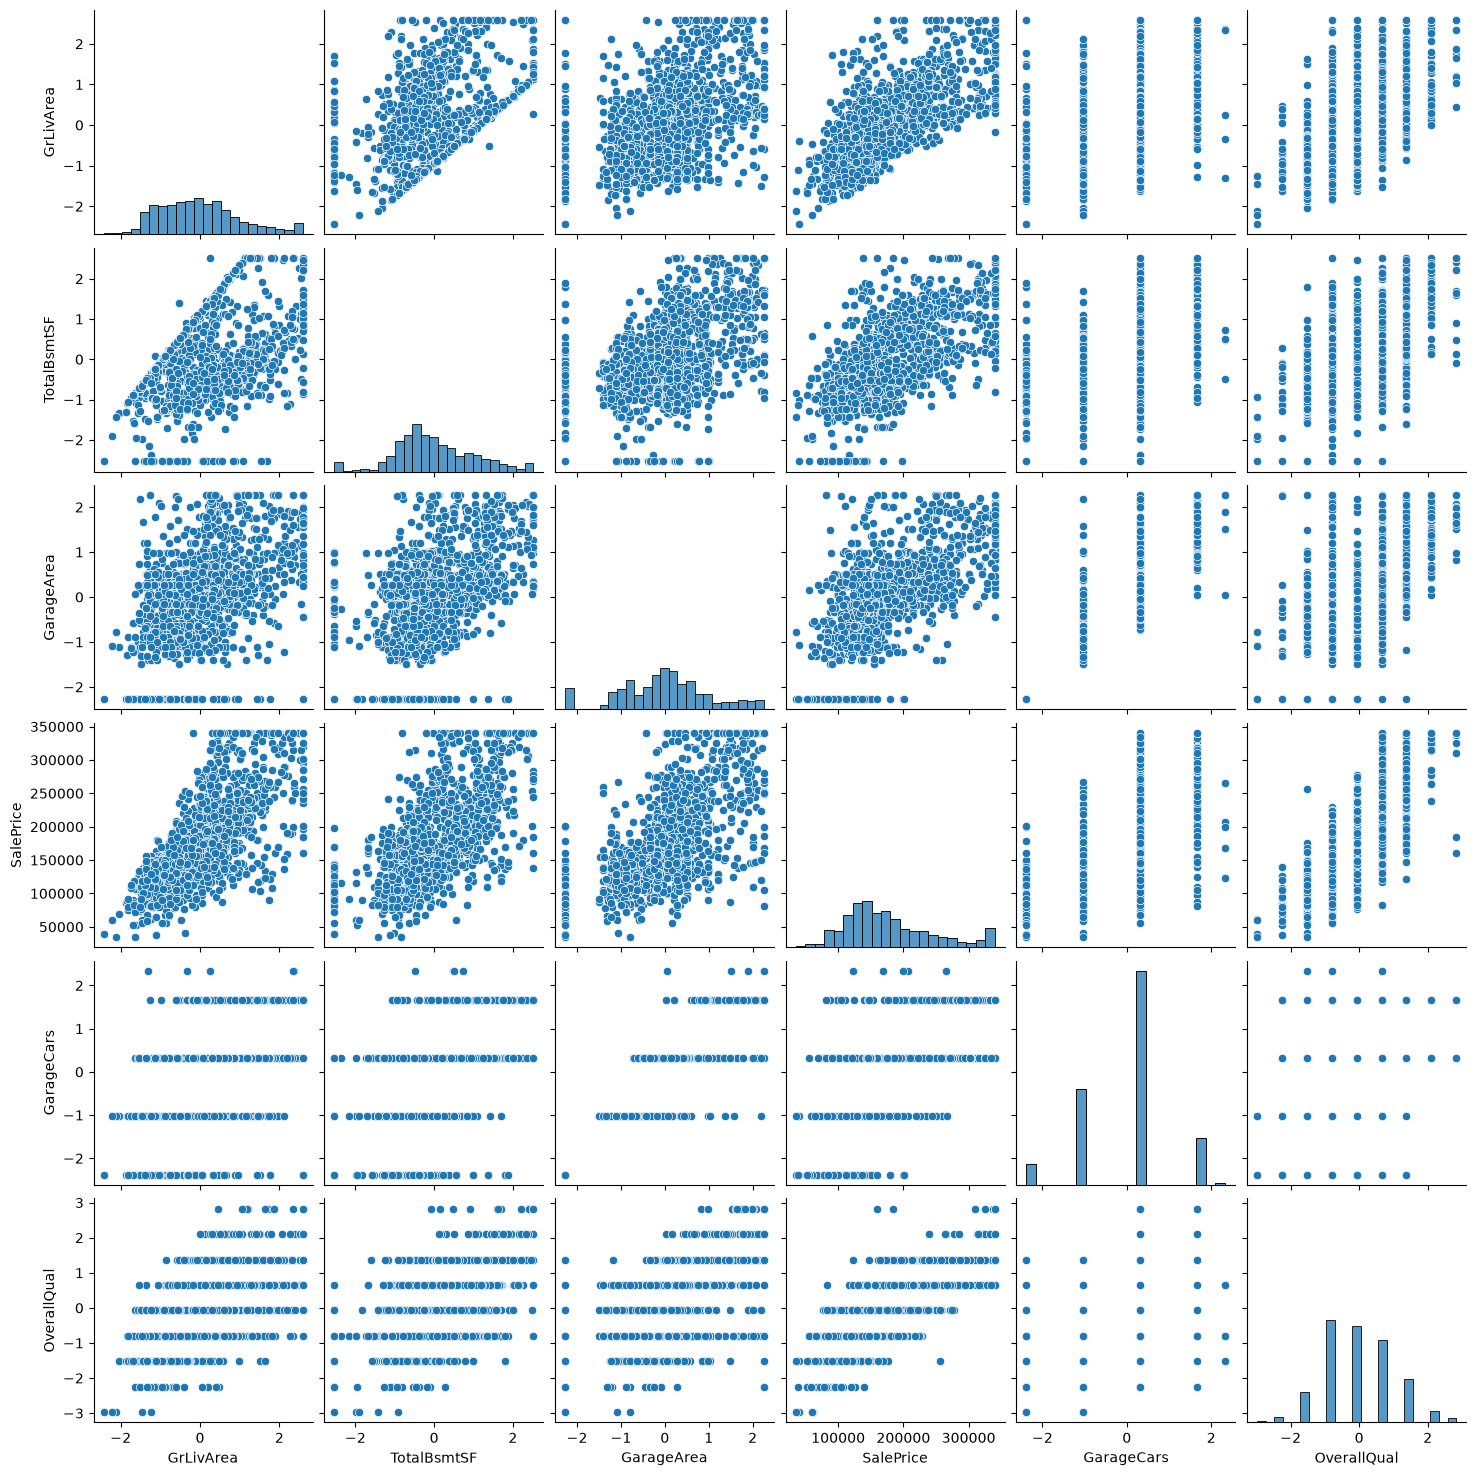

In [35]:
sns.pairplot(train[selected_columns])

plt.show()

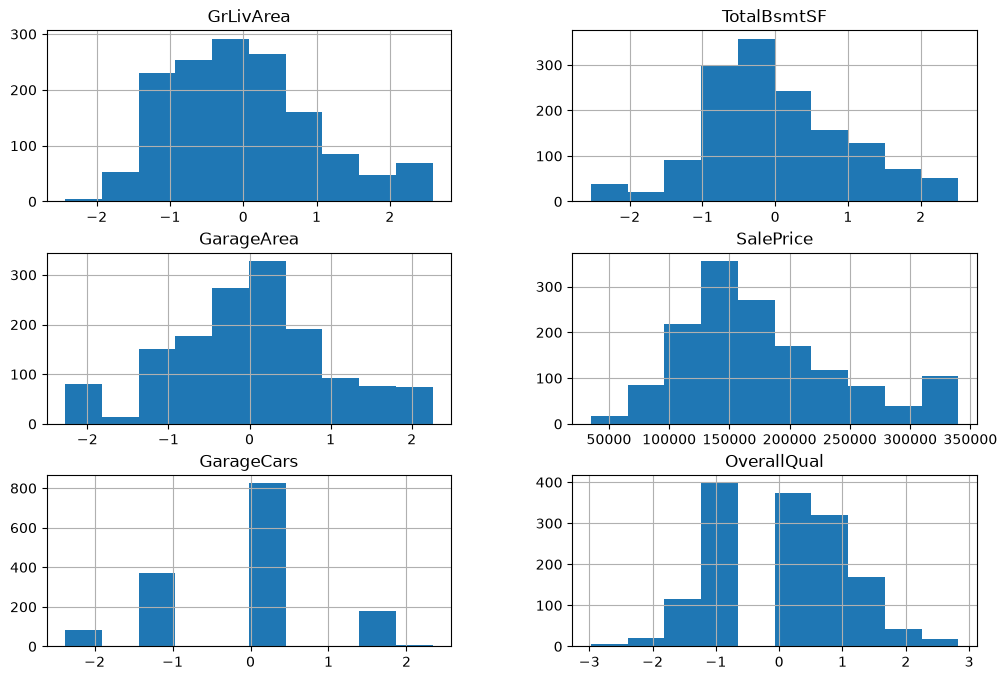

In [36]:
train[selected_columns].hist(
    figsize=(12,8)
)

plt.show()

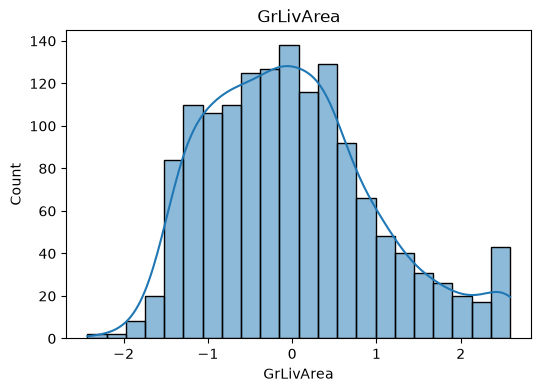

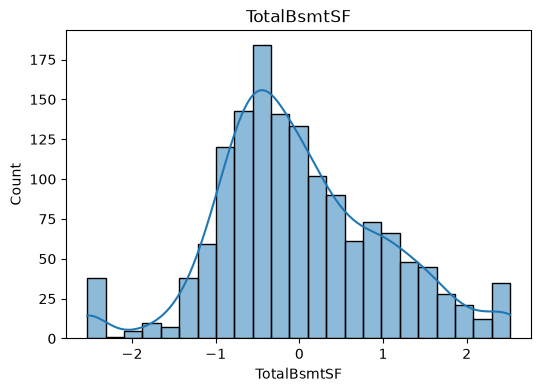

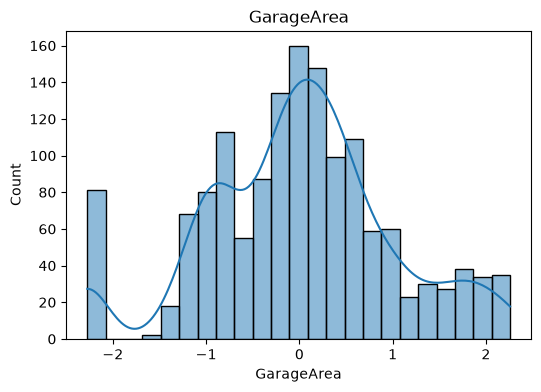

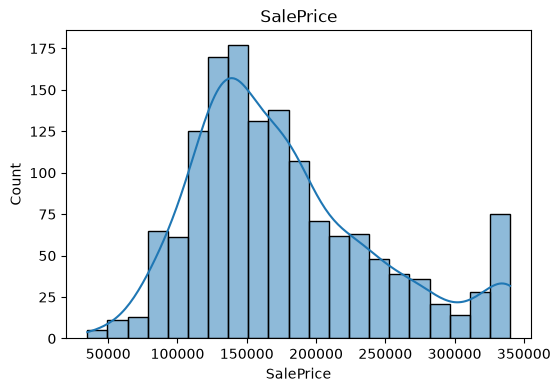

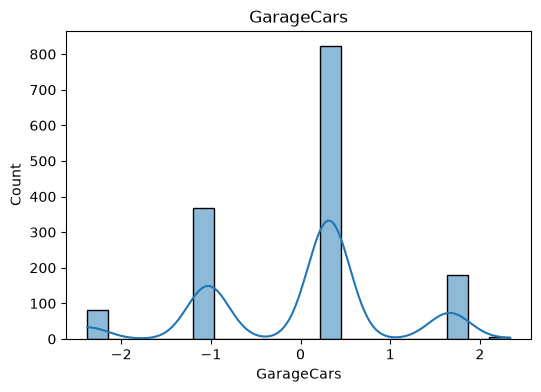

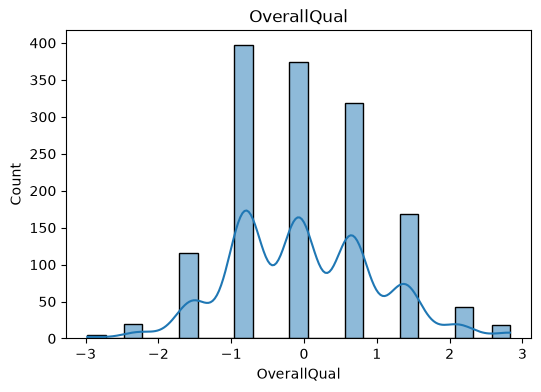

In [37]:
for column in selected_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(
        train[column],
        kde=True
    )

    plt.title(column)

    plt.show()

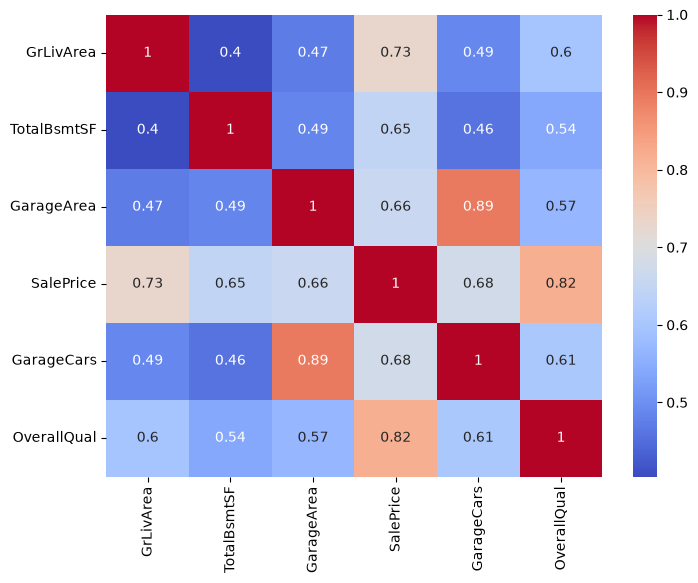

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    train[selected_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()